# rel-amazon Exploratory Data Analysis

Build an analysis-ready table from the RelBench Amazon e-commerce relational dataset, then run the shared EDA utility suite for profiling, distributions, relationships, outliers, and missing data.

## 1. Environment Setup

### 1.1 Load libraries and reusable EDA helpers

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..", "useful-python-scripts-eda")))
from data_profiler import DataProfiler
from distribution_analyzer import DistributionAnalyzer
from correlation_explorer import CorrelationExplorer
from outlier_suite import OutlierSuite
from missing_data_analyzer import MissingDataAnalyzer

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from relbench.datasets import get_dataset

## 2. Dataset Loading

### 2.1 Download and instantiate the rel-hm database

In [2]:
db = get_dataset("rel-amazon", download=True).get_db(upto_test_timestamp=False)

Loading Database object from /Users/edoerner/Library/Caches/relbench/rel-amazon/db...
Done in 475.88 seconds.


### 2.2 Extract source tables

In [3]:
reviews_df = db.table_dict["review"].df
customers_df = db.table_dict["customer"].df
products_df = db.table_dict["product"].df

## 3. Analysis Table Construction

### 3.1 Join reviews with products dataframe

In [4]:
products_cols = ["product_id", "price"]
reviews_cols = [col for col in reviews_df.columns if col not in ["review_text", "summary"]]

df = reviews_df[reviews_cols].merge(products_df[products_cols], on="product_id", how="left")

In [5]:
# If stated by the user, a sample of the dataset is used.
SAMPLE_SIZE = 50000
if SAMPLE_SIZE is not None and len(df) > SAMPLE_SIZE:
    df = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

### 3.2 Cast categorical identifier fields

In [6]:
# Some columns are clearly categorical, so we transform them to string datatype.
categorical_cols = ["customer_id", "product_id"]
for col in categorical_cols:
    df[col] = df[col].astype(str)

### 3.3 Preview the master analysis table

In [7]:
df.head(5)

,review_time,customer_id,product_id,rating,verified,price
0,2014-12-14,222024,29470,5.0,True,14.33
1,2017-07-19,145723,373501,5.0,False,7.99
2,2015-06-08,827792,342496,5.0,False,11.69
3,2016-04-09,470937,308480,1.0,False,10.99
4,2014-06-21,640422,61454,5.0,True,23.61


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   review_time  50000 non-null  datetime64[ns]
 1   customer_id  50000 non-null  str           
 2   product_id   50000 non-null  str           
 3   rating       50000 non-null  float32       
 4   verified     50000 non-null  bool          
 5   price        50000 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float32(1), float64(1), str(2)
memory usage: 2.3 MB


## 4. Comprehensive Data Profiling

### 4.1 Initialize the profiler

In [13]:
# Create profiler.
profiler = DataProfiler(df, high_cardinality_threshold=0.5)

### 4.2 Print the profile summary

In [14]:
# Print summary to console.
profiler.print_summary()

Generating data profile...
Profile generation complete!

DATASET OVERVIEW
Total Rows: 50000
Total Columns: 6
Total Missing Cells: 0
Total Memory Mb: 2.33
Duplicate Rows: 0
Duplicate Percentage: 0.0
Numeric Columns: 2
Categorical Columns: 2
Datetime Columns: 1
Boolean Columns: 1

NUMERIC COLUMNS SUMMARY
  name  null_percentage    mean    std  min_value  max_value  skewness
rating              0.0  4.3858  0.988        1.0       5.00   -1.7784
 price              0.0 14.9184 24.949        0.0    1702.22   31.0456

CATEGORICAL COLUMNS SUMMARY
       name  unique_count  null_percentage top_value  top_percentage  is_high_cardinality
customer_id         46546              0.0       259            0.02                 True
 product_id         36603              0.0     75687            0.16                 True

DATA QUALITY ISSUES
No major issues detected



### 4.3 Generate the full profile report

In [11]:
# Get detailed report.
profiler_report = profiler.generate_full_profile()
print(profiler_report["overview"])
print("--" * 20)
print(profiler_report["numeric_profiles"])
print("--" * 20)
print(profiler_report["categorical_profiles"])
print("--" * 20)
print(profiler_report["data_quality_issues"])

Generating data profile...
Profile generation complete!
{'total_rows': 50000, 'total_columns': 6, 'total_missing_cells': np.int64(0), 'total_memory_mb': np.float64(2.33), 'duplicate_rows': np.int64(0), 'duplicate_percentage': np.float64(0.0), 'numeric_columns': 2, 'categorical_columns': 2, 'datetime_columns': 1, 'boolean_columns': 1}
----------------------------------------
     name    dtype  non_null_count  null_count  null_percentage  unique_count  \
0  rating  float32           50000           0              0.0             5   
1   price  float64           50000           0              0.0          3663   

   unique_percentage  memory_bytes  min_value  max_value     mean  median  \
0               0.01        200132        1.0       5.00   4.3858   5.000   
1               7.33        400132        0.0    1702.22  14.9184  12.575   

      std   q25    q75  skewness   kurtosis  zeros_count  zeros_percentage  \
0   0.988  4.00   5.00   -1.7784     2.6661            0             

## 5. Distribution Analysis

### 5.1 Initialize the distribution analyzer

In [16]:
analyzer = DistributionAnalyzer(df, exclude_columns=["customer_id"])

### 5.2 Generate distribution statistics

In [17]:
# Generate distribution report
analyzer_report = analyzer.generate_distribution_report()
print(analyzer_report)

   column  count     mean  median  mode     std  skewness   kurtosis  \
0  rating  50000   4.3858   5.000  5.00   0.988   -1.7784     2.6661   
1   price  50000  14.9184  12.575  9.99  24.949   31.0456  1334.1481   

   is_normal normality_p_value        distribution_type  outlier_count  \
0      False              None   Left-skewed (Negative)           3280   
1      False              None  Right-skewed (Positive)           3613   

   outlier_percentage  
0                6.56  
1                7.23  


### 5.3 Identify highly skewed variables

In [18]:
# Identify highly skewed columns
skewed = analyzer_report[abs(analyzer_report['skewness']) > 2]
print(f"Highly skewed columns: {skewed['column'].tolist()}")

Highly skewed columns: ['price']


### 5.4 Visualize numeric and categorical distributions

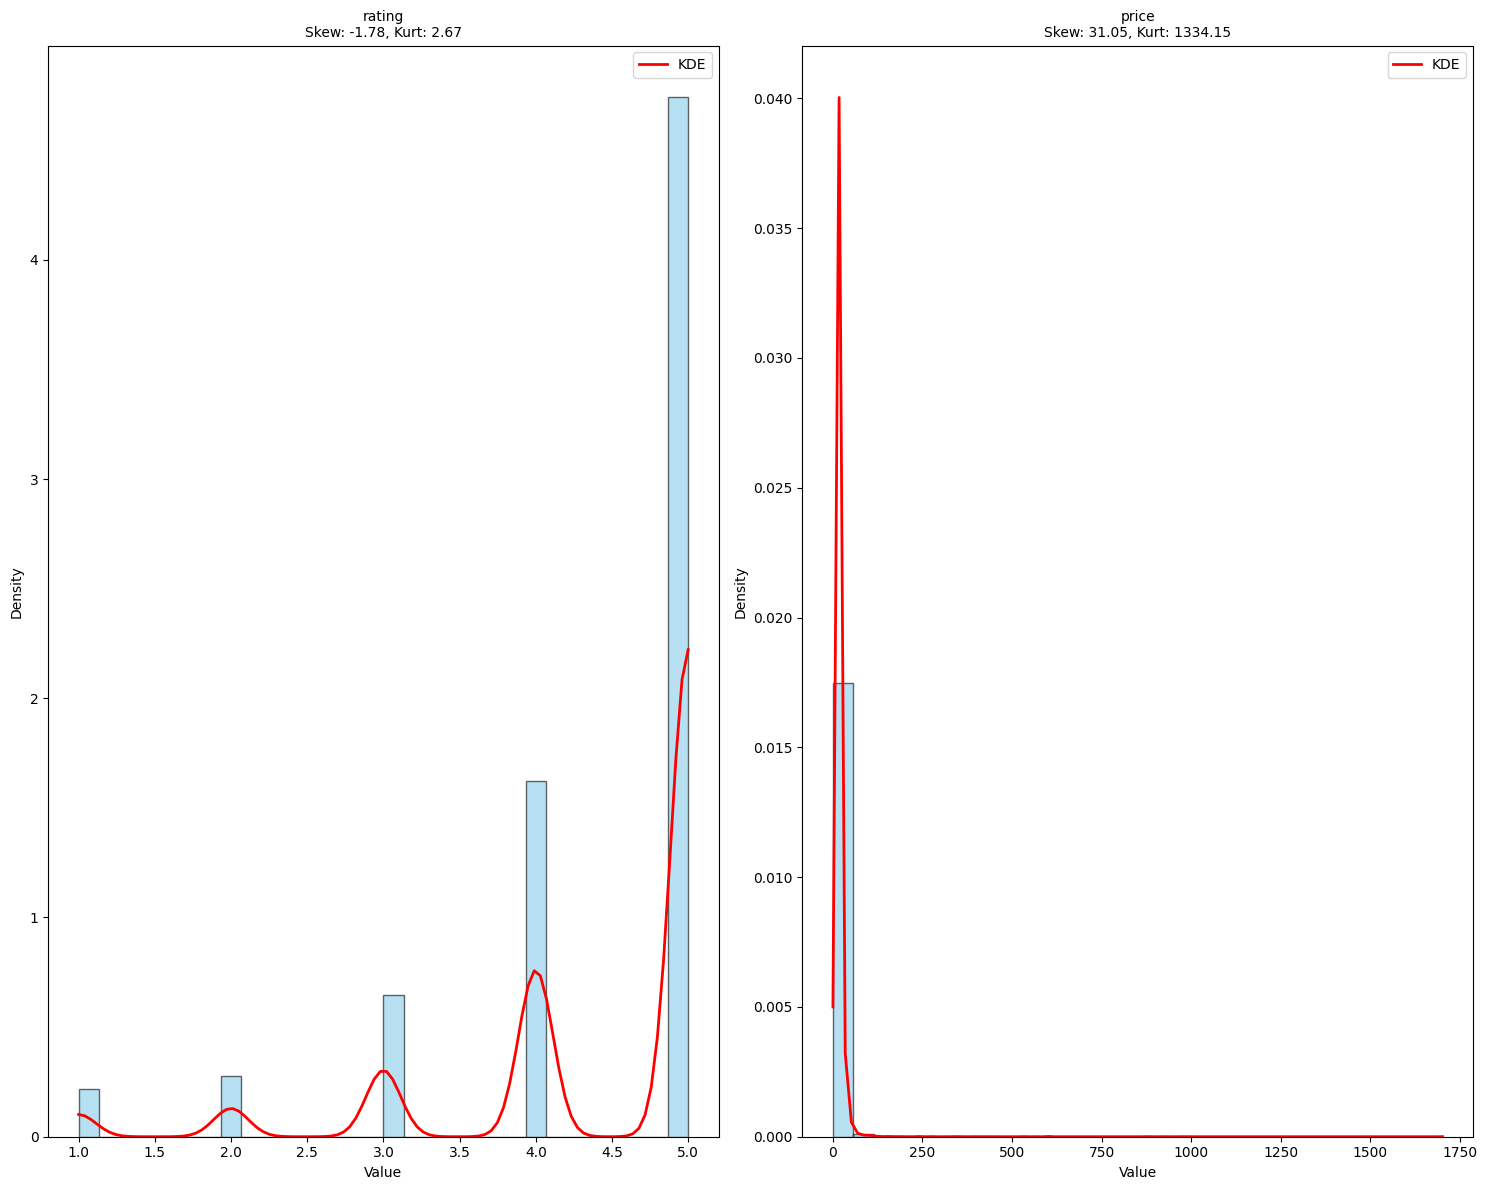

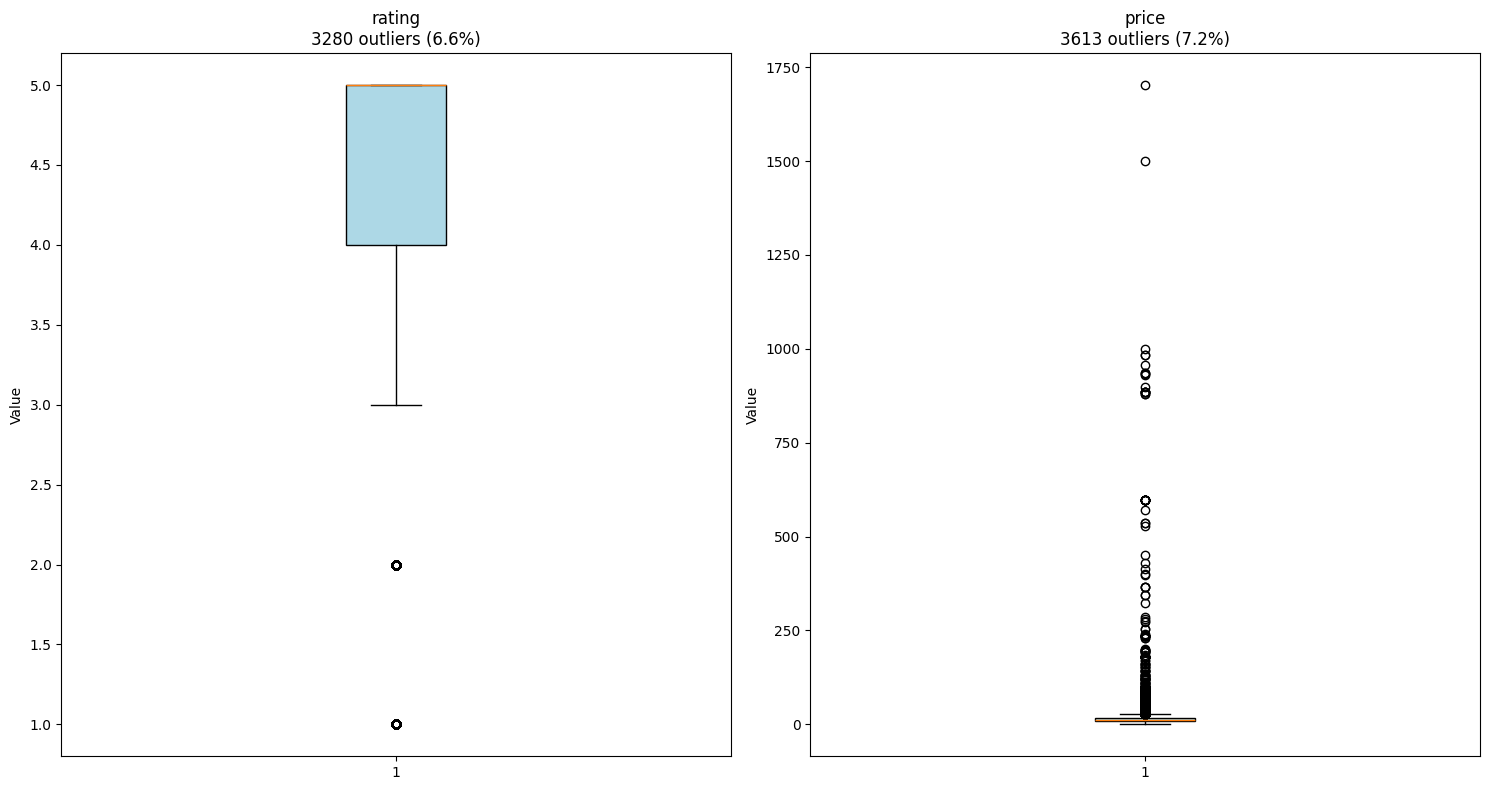

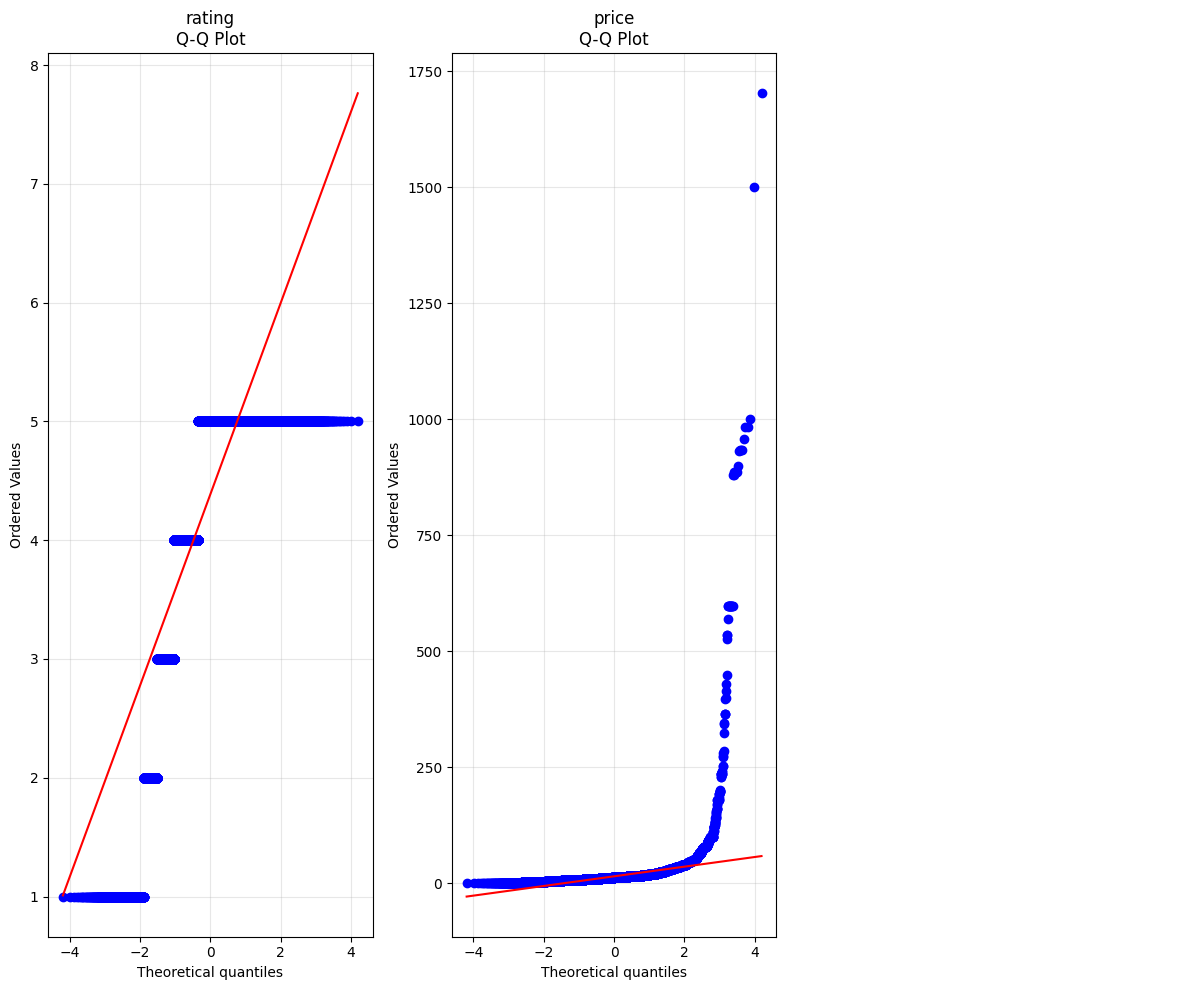

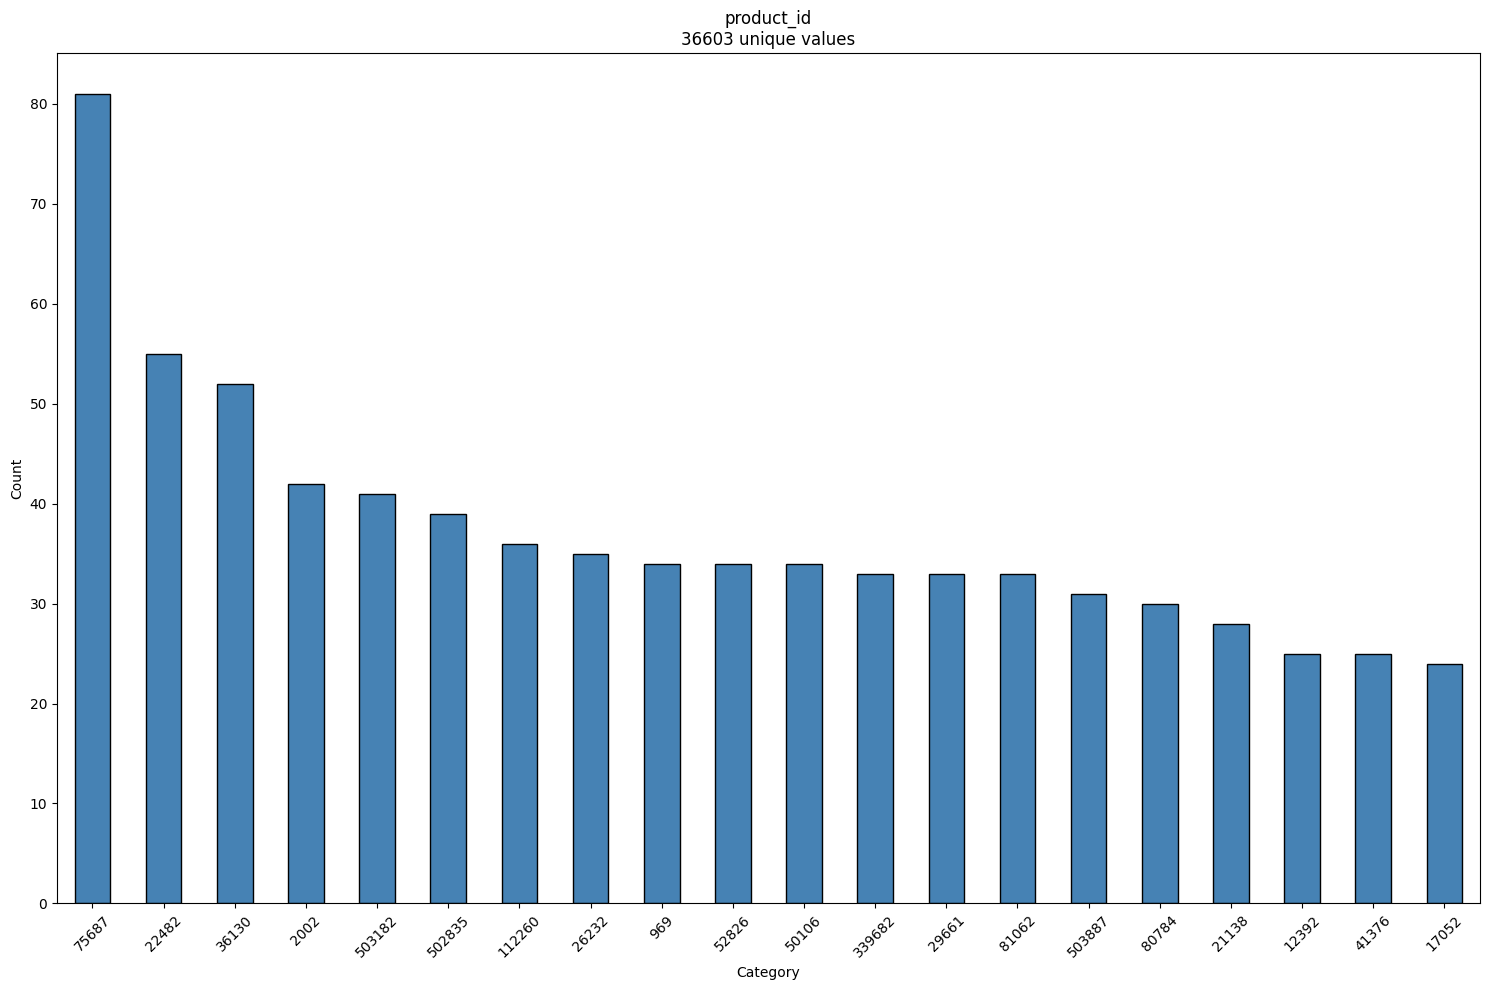

In [19]:
# Visualize distributions
analyzer.plot_numeric_distributions(max_cols=10)
analyzer.plot_boxplots()
analyzer.plot_qq_plots()
analyzer.plot_categorical_distributions()

## 6. Correlation and Relationship Exploration

### 6.1 Initialize the relationship explorer

In [20]:
explorer = CorrelationExplorer(df, exclude_columns=["customer_id"])

### 6.2 Find strongly correlated feature pairs

In [21]:
# Find high correlations
high_corr = explorer.find_high_correlations(threshold=0.7, method='pearson')
print(high_corr)

Empty DataFrame
Columns: []
Index: []


### 6.3 Check multicollinearity with VIF

In [22]:
# Check for multicollinearity
vif = explorer.calculate_vif()
problematic = vif[vif['vif'] > 10]
print(f"Features with high multicollinearity:\n{problematic}")

Features with high multicollinearity:
Empty DataFrame
Columns: [feature, vif, r_squared, multicollinearity]
Index: []


### 6.4 Run mutual information analysis when a target exists

In [23]:
# Mutual information with target
if 'target' in df.columns:
    mi_scores = explorer.mutual_information_analysis('target')
    print(f"Top features:\n{mi_scores.head(10)}")

### 6.5 Visualize pairwise relationships

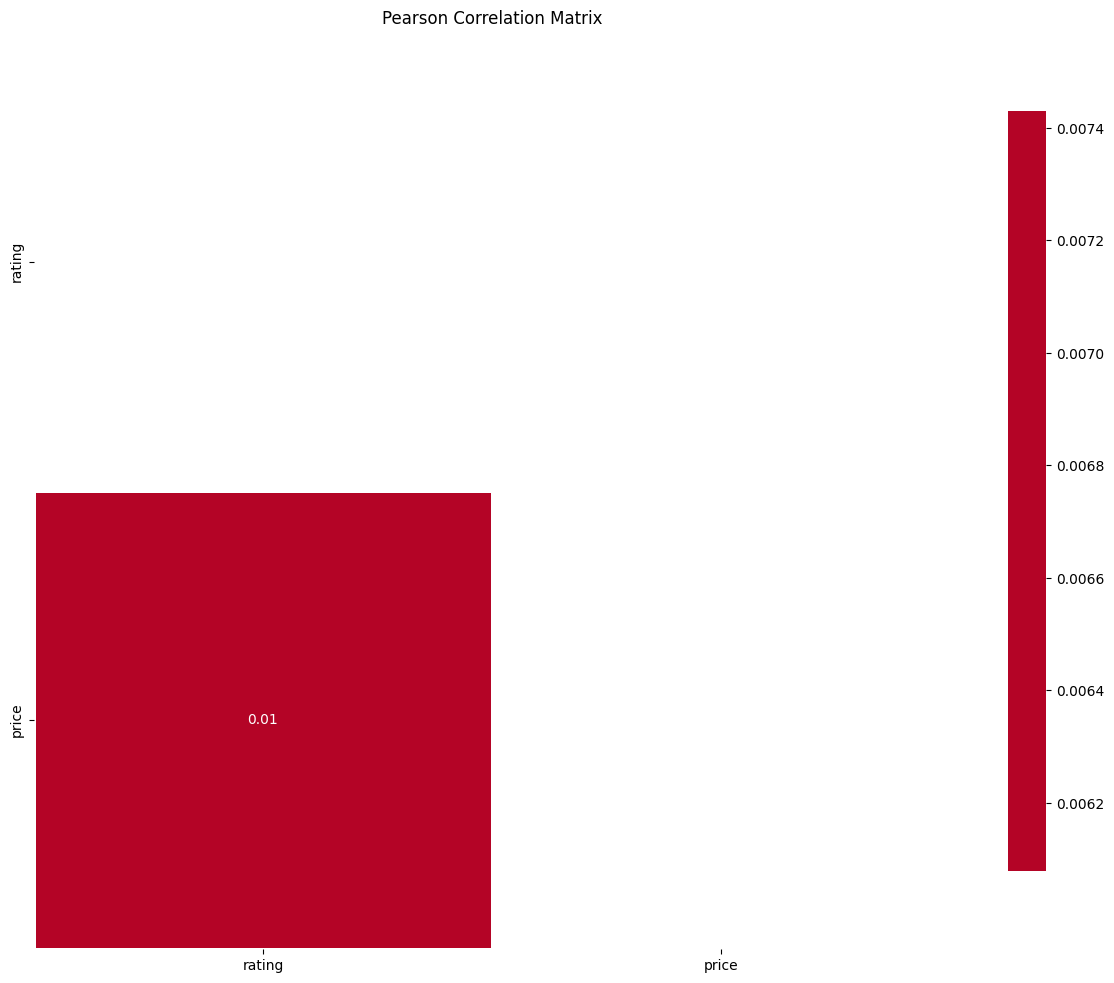

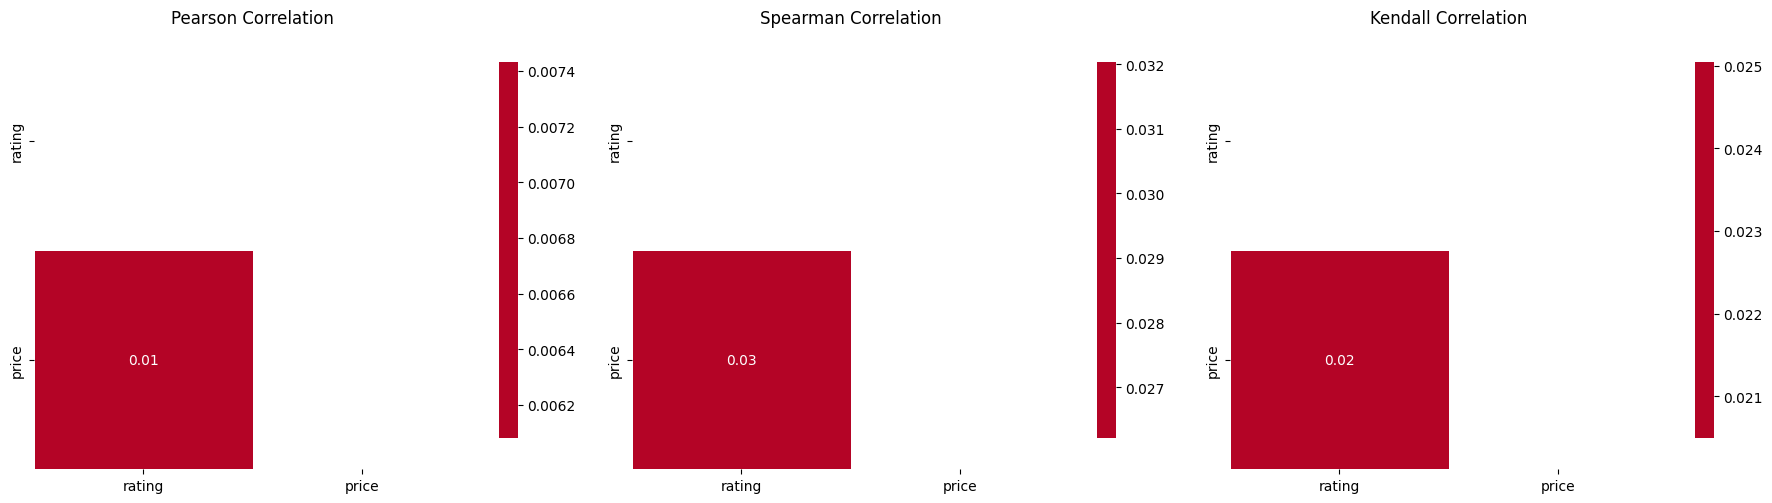

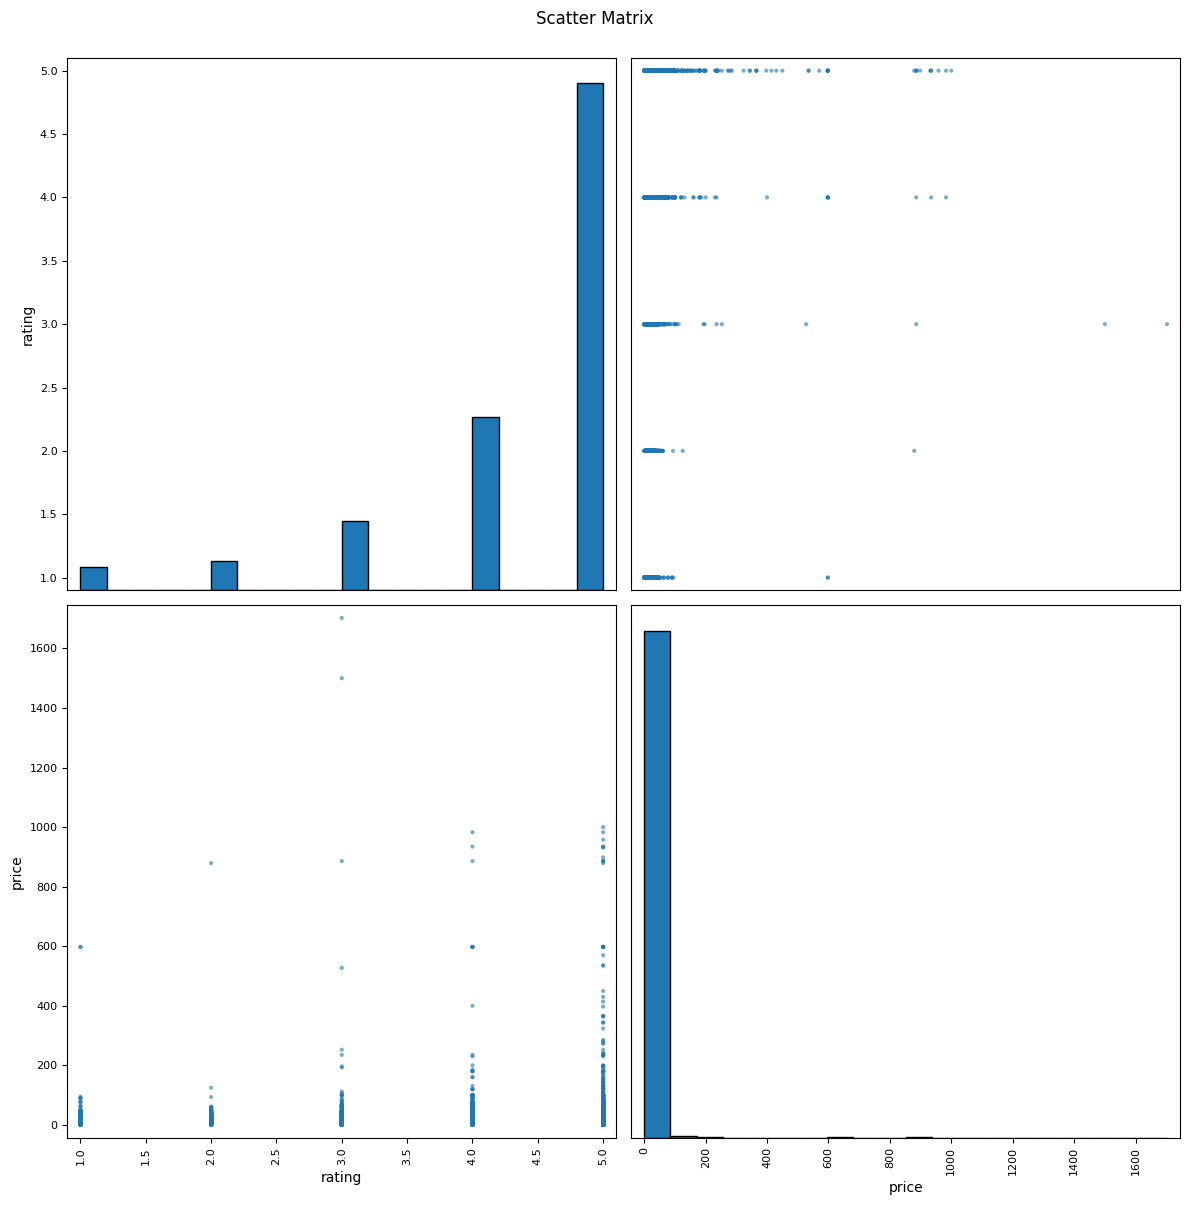

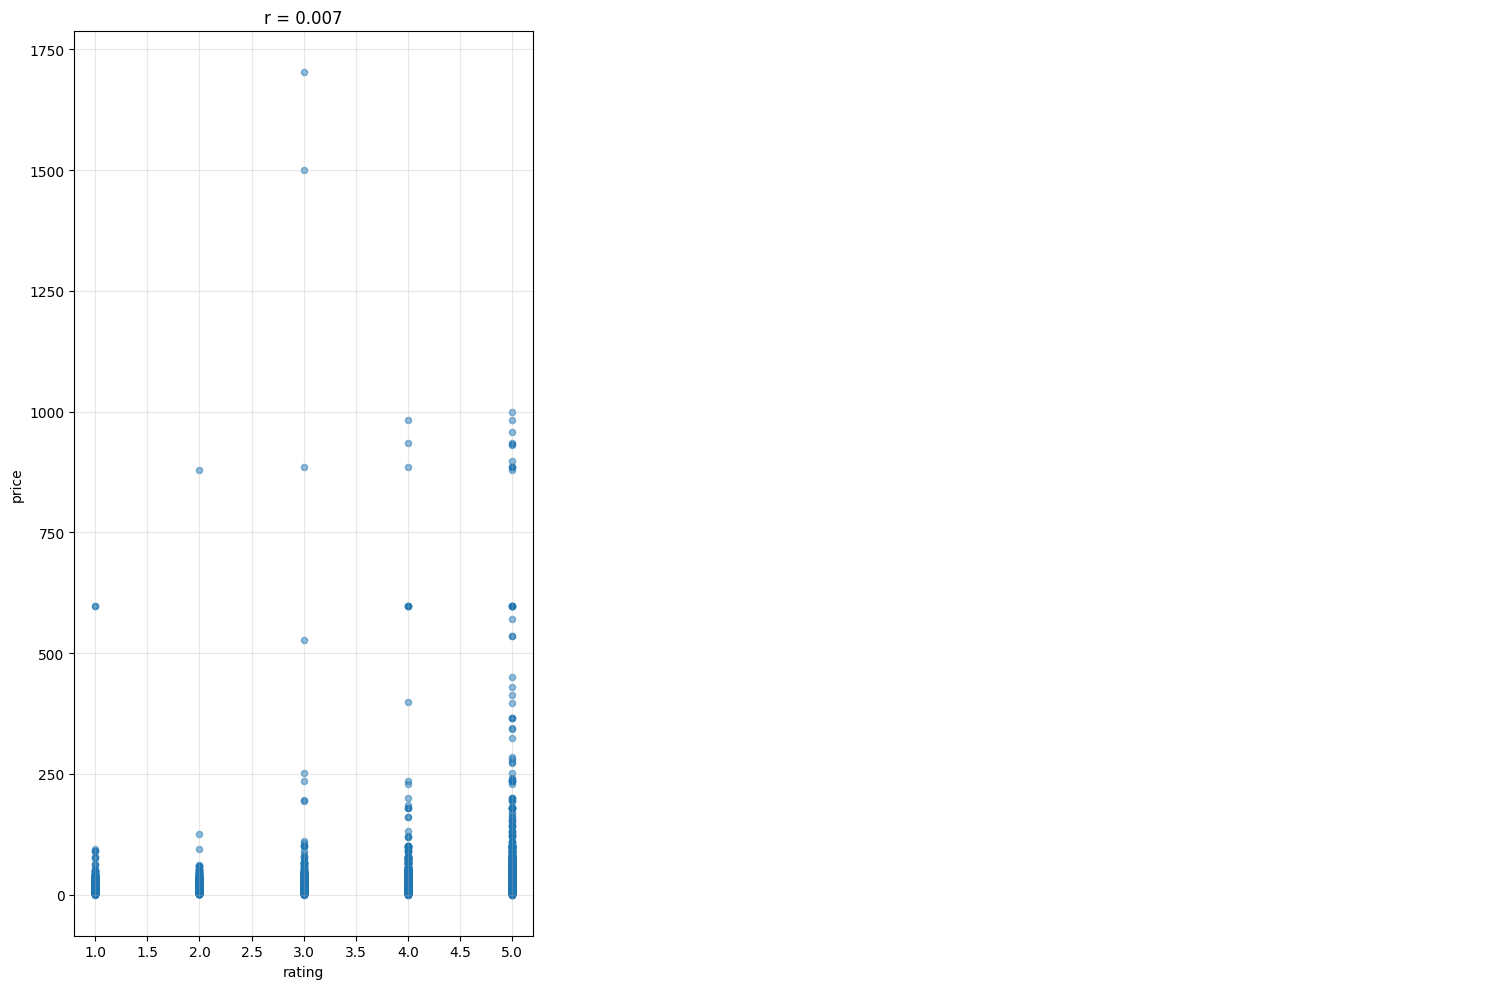

In [24]:
# Visualize
explorer.plot_correlation_heatmap(method='pearson')
explorer.plot_correlation_comparison()
explorer.plot_scatter_matrix(max_cols=5)
explorer.plot_top_correlations(n_pairs=10)

## 7. Outlier Detection

### 7.1 Initialize the outlier analysis suite

In [25]:
suite = OutlierSuite(df, exclude_columns=["customer_id"])

### 7.2 Compare outlier detection methods

In [26]:
# Compare methods across all columns
summary = suite.compare_methods_all_columns()
print(summary)

   column  total_outliers_iqr  total_outliers_zscore  \
0  rating                3280                   1444   
1   price                3613                    191   

   total_outliers_modified_zscore  consensus_outliers  percentage_consensus  
0                               0                1444                  2.89  
1                            2510                2510                  5.02  


### 7.3 Inspect price outliers

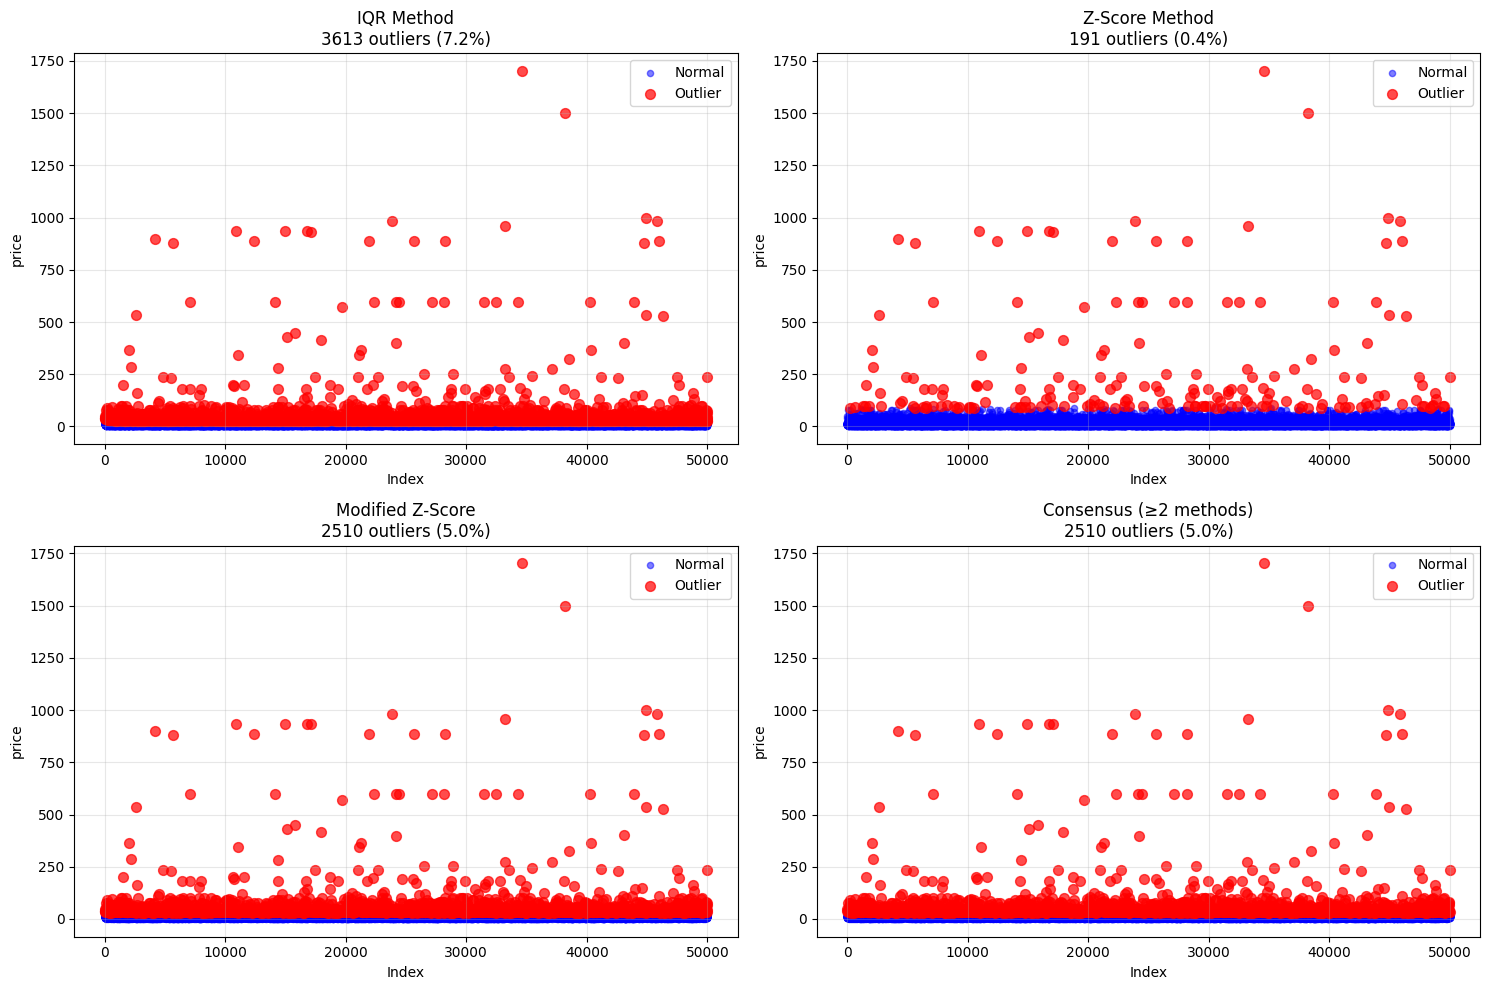

In [27]:
# Analyze specific column
col = "price"
suite.plot_outlier_comparison(col)

### 7.4 Detect and visualize multivariate outliers

python(17592) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Found 4948 multivariate outliers


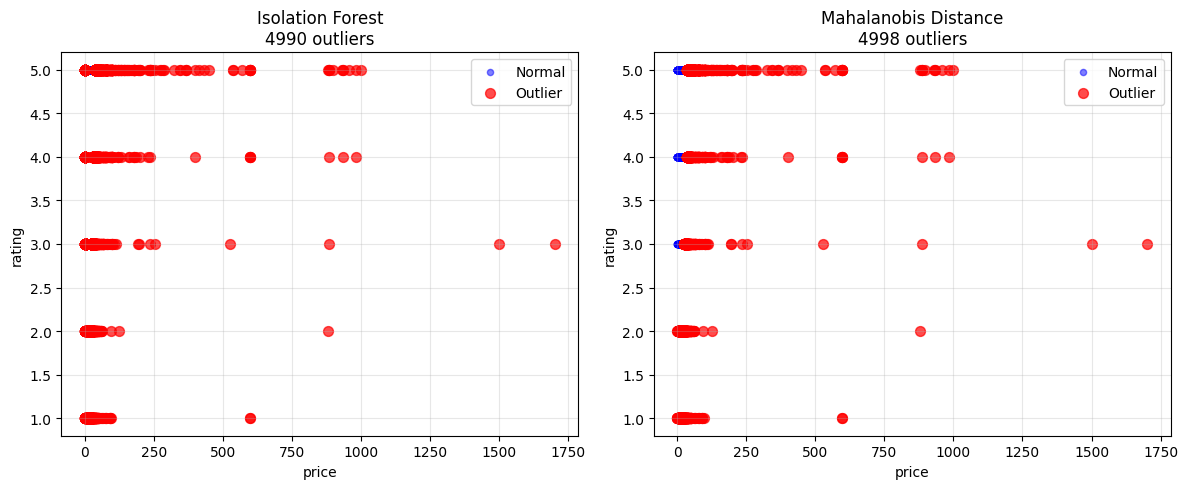

In [28]:
# Detect multivariate outliers
iso_outliers = suite.detect_isolation_forest_outliers(contamination=0.1)
print(f"Found {iso_outliers.sum()} multivariate outliers")

feature1 = "price"
feature2 = "rating"
suite.plot_multivariate_outliers([feature1, feature2])

### 7.5 Estimate the impact of price outliers

In [29]:
# Analyze outlier impact
col = "price"
impact = suite.analyze_outlier_impact(col)
print(impact)

{'column': 'price', 'mean_with_outliers': np.float64(14.9184), 'mean_without_outliers': np.float64(12.5706), 'mean_difference': np.float64(2.3477), 'median_with_outliers': np.float64(12.575), 'median_without_outliers': np.float64(12.0), 'std_with_outliers': np.float64(24.949), 'std_without_outliers': np.float64(5.2931)}


## 8. Missing Data Analysis

### 8.1 Initialize the missing data analyzer

In [30]:
analyzer = MissingDataAnalyzer(df, exclude_columns=["customer_id"])

### 8.2 Generate missingness summaries and recommendations

In [31]:
# Generate full report
report = analyzer.generate_full_report()

print("Missing Value Summary:")
print(report['summary'])

print("\nMissingness Patterns (co-occurrence):")
print(report['patterns'])

print("\nMissingness Classifications:")
print(report['classifications'])

print("\nImputation Recommendations:")
print(report['recommendations'])

Missing Value Summary:
Empty DataFrame
Columns: []
Index: []

Missingness Patterns (co-occurrence):
Empty DataFrame
Columns: []
Index: []

Missingness Classifications:
Empty DataFrame
Columns: []
Index: []

Imputation Recommendations:
Empty DataFrame
Columns: []
Index: []


### 8.3 Visualize missing data patterns

In [ ]:
# Visualize patterns
analyzer.plot_missing_bar()
analyzer.plot_missing_heatmap(max_cols=30)
analyzer.plot_missing_correlation()

### 8.4 Classify missingness and choose an imputation strategy

In [ ]:
# Classify specific column
col = ""
classification = analyzer.classify_missingness_type(col)
recommendation = analyzer.recommend_strategy(col)
print(f"Missingness type: {classification['missingness_type']}")
print(f"Recommendation: {recommendation}")